In [1]:
import cv2
import os
import random

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

2026-08-05 13:58:10.690289: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [3]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 0.001

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2567 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Found 100 files belonging to 20 classes.


In [5]:
class_names = train_ds.class_names

print("Classes:")

for i, c in enumerate(class_names):
    print(i, c)

Classes:
0 ARCIGERA FLOWER MOTH
1 ATLAS MOTH
2 BANDED TIGER MOTH
3 BIRD CHERRY ERMINE MOTH
4 CINNABAR MOTH
5 CLEARWING MOTH
6 COMET MOTH
7 EMPEROR GUM MOTH
8 GARDEN TIGER MOTH
9 GIANT LEOPARD MOTH
10 HERCULES MOTH
11 HUMMING BIRD HAWK MOTH
12 IO MOTH
13 LUNA MOTH
14 MADAGASCAN SUNSET MOTH
15 OLEANDER HAWK MOTH
16 POLYPHEMUS MOTH
17 ROSY MAPLE MOTH
18 SIXSPOT BURNET MOTH
19 WHITE LINED SPHINX MOTH


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

valid_ds = valid_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

### Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.GaussianNoise(0.05)

])

### Build EfficientNetB0

In [8]:
base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

In [9]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    20,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,075,191 (15.55 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [13]:
history = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    callbacks=[early_stop]

)

Epoch 1/20


81/81 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5882 - loss: 1.6172 - val_accuracy: 0.9000 - val_loss: 0.5559
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8746 - loss: 0.6013 - val_accuracy: 0.9400 - val_loss: 0.3256
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8999 - loss: 0.4217 - val_accuracy: 0.9600 - val_loss: 0.2678
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9244 - loss: 0.3300 - val_accuracy: 0.9700 - val_loss: 0.2224
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9279 - loss: 0.2919 - val_accuracy: 0.9700 - val_loss: 0.2133
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9342 - loss: 0.2588 - val_accuracy: 0.9700 - val_loss: 0.2028
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9423 - loss: 0.2256 - val_accuracy: 0.9700 - val_loss: 0.1972
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9474 - loss: 0.2107 - val_accuracy: 0.9600 - val_loss: 0.1931
Ep

### Accuracy Curve

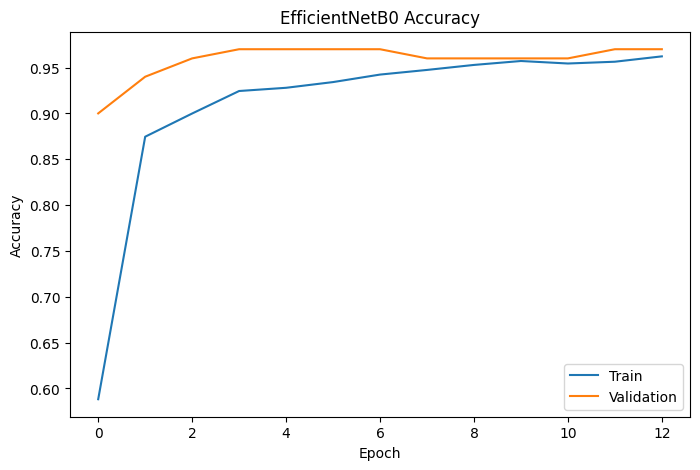

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("EfficientNetB0 Accuracy")

plt.legend()

plt.show()

### Loss Curve

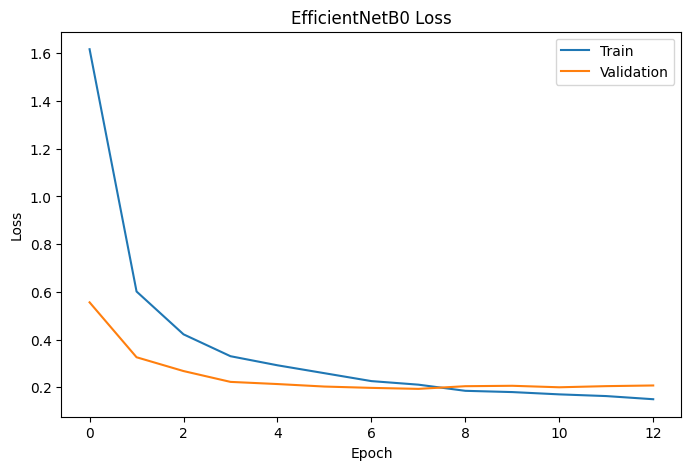

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("EfficientNetB0 Loss")

plt.legend()

plt.show()

### Evaluate Model

In [16]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(
    "Test Accuracy:",
    test_acc
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 675ms/step - accuracy: 0.9700 - loss: 0.0958
Test Accuracy: 0.9700000286102295


### Predictions

In [17]:
y_true = []

for images, labels in test_ds:

    y_true.extend(
        labels.numpy()
    )

2026-08-05 14:17:48.331073: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
predictions = model.predict(
    test_ds
)

y_pred = np.argmax(
    predictions,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


In [19]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(y_true.shape)
print(y_pred.shape)

prediction_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

prediction_df.to_csv(
    "EfficientNetB0_predictions.csv",
    index=False
)

print("EfficientNetB0_predictions.csv saved.")

(100,)
(100,)
EfficientNetB0_predictions.csv saved.


### Confusion Matrix

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred
)

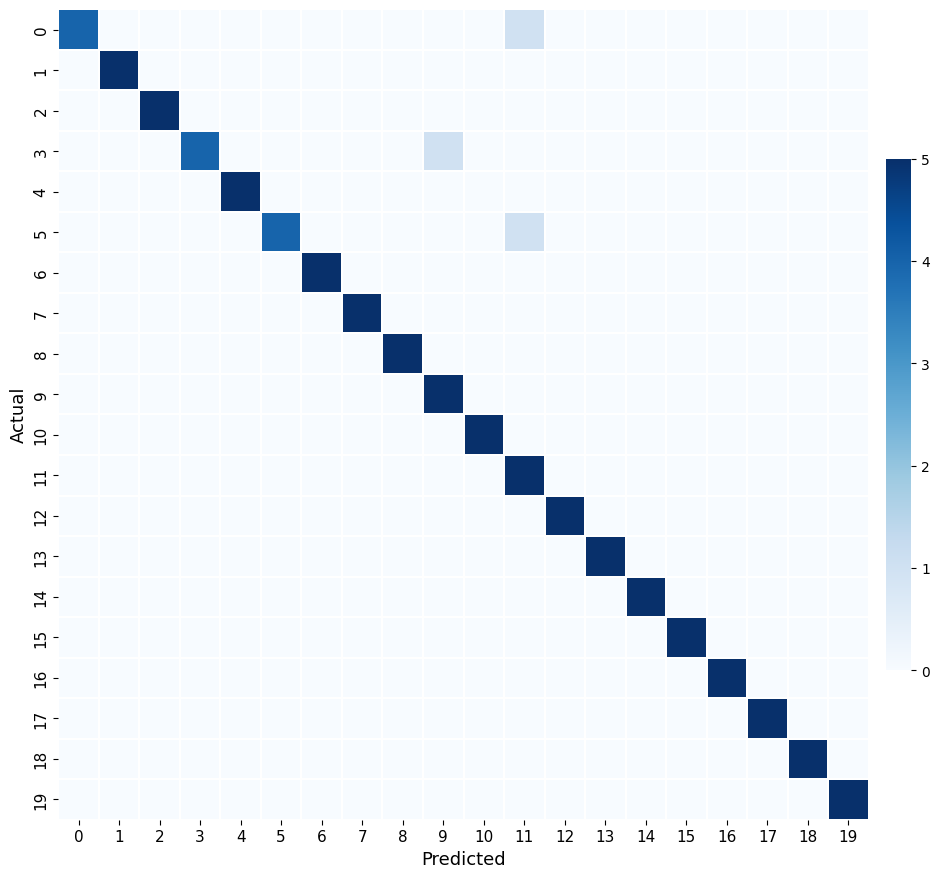

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

### Classification Report

In [22]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )
)

                         precision    recall  f1-score   support

   ARCIGERA FLOWER MOTH       1.00      0.80      0.89         5
             ATLAS MOTH       1.00      1.00      1.00         5
      BANDED TIGER MOTH       1.00      1.00      1.00         5
BIRD CHERRY ERMINE MOTH       1.00      0.80      0.89         5
          CINNABAR MOTH       1.00      1.00      1.00         5
         CLEARWING MOTH       1.00      0.80      0.89         5
             COMET MOTH       1.00      1.00      1.00         5
       EMPEROR GUM MOTH       1.00      1.00      1.00         5
      GARDEN TIGER MOTH       1.00      1.00      1.00         5
     GIANT LEOPARD MOTH       0.83      1.00      0.91         5
          HERCULES MOTH       1.00      1.00      1.00         5
 HUMMING BIRD HAWK MOTH       0.71      1.00      0.83         5
                IO MOTH       1.00      1.00      1.00         5
              LUNA MOTH       1.00      1.00      1.00         5
 MADAGASCAN SUNSET MOTH 

In [23]:
results = {
    "accuracy": test_acc,
    "loss": test_loss
}

print(results)

{'accuracy': 0.9700000286102295, 'loss': 0.09577681869268417}


In [24]:
model.save(
    "EfficientNetB0.keras"
)

### Grad-CAM

In [25]:
misclassified = []

for images, labels in test_ds:

    preds = model.predict(images, verbose=0)

    pred_labels = np.argmax(preds, axis=1)

    true_labels = labels.numpy()

    for i in range(len(images)):

        if pred_labels[i] != true_labels[i]:

            misclassified.append({
                "image": images[i],
                "true": true_labels[i],
                "pred": pred_labels[i]
            })

print(len(misclassified))

3


2026-08-05 14:18:07.070217: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [26]:
last_conv_layer = base_model.get_layer("top_conv")

feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)

print("Feature extractor created.")

Feature extractor created.


In [27]:
classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

x = classifier_input

found = False

for layer in base_model.layers:

    if layer.name == "top_conv":
        found = True
        continue

    if found:
        x = layer(x)

# Classification head
x = model.layers[-3](x)      # GlobalAveragePooling2D
x = model.layers[-2](x)      # Dropout
x = model.layers[-1](x)      # Dense

classifier_model = tf.keras.Model(classifier_input, x)

print("Classifier model created.")

Classifier model created.


In [ ]:
def plot_gradcam(sample, index, alpha=0.45):

    # -----------------------
    # image
    # -----------------------
    image = sample["image"].numpy().astype("float32")
    image_batch = np.expand_dims(image, axis=0)

    # -----------------------
    # Grad-CAM
    # -----------------------
    with tf.GradientTape() as tape:

        feature_maps = feature_extractor(image_batch)
        
        tape.watch(feature_maps)
        
        predictions = classifier_model(feature_maps)

        pred_index = sample["pred"]

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, feature_maps)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    feature_maps = feature_maps[0]

    heatmap = feature_maps @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap) + 1e-8

    heatmap = heatmap.numpy()

    # -----------------------
    # Resize
    # -----------------------
    heatmap = cv2.resize(
        heatmap,
        (224, 224)
    )

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    original = image.astype("uint8")

    overlay = cv2.addWeighted(
        original,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    # -----------------------
    # Save Original
    # -----------------------
    plt.figure(figsize=(5,5))
    plt.imshow(original)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, f"original_{index+1}.png"),
        dpi=600,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close()

    # -----------------------
    # Save Heatmap
    # -----------------------
    plt.figure(figsize=(5,5))
    plt.imshow(heatmap_color)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, f"heatmap_{index+1}.png"),
        dpi=600,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close()

    # -----------------------
    # Save Overlay
    # -----------------------
    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        os.path.join(save_dir, f"overlay_{index+1}.png"),
        dpi=600,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close()

    print(f"Saved Figure {index+1}")

In [29]:
for i, sample in enumerate(misclassified):
    plot_gradcam(sample, i)

Saved Figure 1
Saved Figure 2
Saved Figure 3
